In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:

data=pd.read_csv('HR_comma_sep_ML.csv')
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
print("--- Starting Data Preprocessing ---")

--- Starting Data Preprocessing ---


In [4]:

print(data.head())


   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

In [5]:
data.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [6]:
data.salary.value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [8]:
data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
data.dropna()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [10]:
data.select_dtypes

<bound method DataFrame.select_dtypes of        satisfaction_level  last_evaluation  number_project  \
0                    0.38             0.53               2   
1                    0.80             0.86               5   
2                    0.11             0.88               7   
3                    0.72             0.87               5   
4                    0.37             0.52               2   
...                   ...              ...             ...   
14994                0.40             0.57               2   
14995                0.37             0.48               2   
14996                0.37             0.53               2   
14997                0.11             0.96               6   
14998                0.37             0.52               2   

       average_montly_hours  time_spend_company  Work_accident  left  \
0                       157                   3              0     1   
1                       262                   6              0     1  

In [11]:
data.duplicated().sum()

np.int64(3008)

In [12]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
14994     True
14995     True
14996     True
14997     True
14998     True
Length: 14999, dtype: bool

In [13]:
data.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [14]:
data = pd.get_dummies(data, columns=['Department', 'salary'], drop_first=True)


In [15]:
data=data.astype(int)
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0,0,2,157,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,0,0,5,262,6,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,0,0,7,272,4,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,0,0,5,223,5,0,1,0,0,0,0,0,0,0,1,0,0,1,0
4,0,0,2,159,3,0,1,0,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0,0,2,151,3,0,1,0,0,0,0,0,0,0,0,1,0,1,0
14995,0,0,2,160,3,0,1,0,0,0,0,0,0,0,0,1,0,1,0
14996,0,0,2,143,3,0,1,0,0,0,0,0,0,0,0,1,0,1,0
14997,0,0,6,280,4,0,1,0,0,0,0,0,0,0,0,1,0,1,0


In [16]:
X=data.drop("left", axis=1)


In [17]:
y=data["left"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
print("Preprocessing completed successfully")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Preprocessing completed successfully
Training data: (11999, 18)
Testing data: (3000, 18)


In [21]:
print("Preprocessing complete. Moving to model training...\n")

Preprocessing complete. Moving to model training...



# MACHINE LEARNING

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    silhouette_score, davies_bouldin_score)



In [23]:
# K-NEAREST NEIGHBORS (KNN)
print("--- 1. K-Nearest Neighbors (KNN) ---")


--- 1. K-Nearest Neighbors (KNN) ---


In [24]:
# Initialize the model (using k=5 as a standard starting point)
knn_model = KNeighborsClassifier(n_neighbors=5)

In [25]:
# Train the model using the scaled training data
knn_model.fit(X_train, y_train)

# Make predictions on the test set
knn_predictions = knn_model.predict(X_test)

In [26]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%\n")  #FLOTING POINTS

KNN Accuracy: 93.23%



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

[]

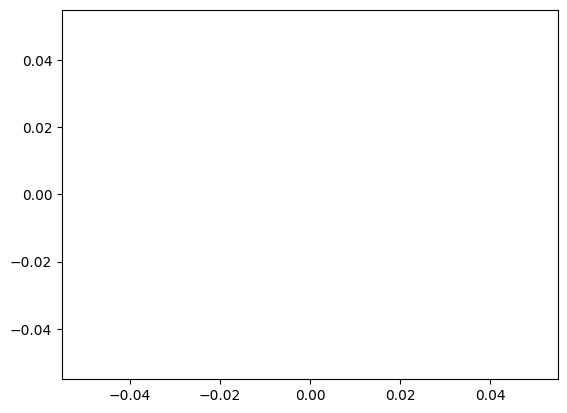

In [28]:
plt.plot()

In [29]:
print("--- KNN Classifier Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, knn_predictions):.4f}")
print(f"Precision: {precision_score(y_test, knn_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, knn_predictions):.4f}")
print(f"F1-Score:  {f1_score(y_test, knn_predictions):.4f}\n")

--- KNN Classifier Metrics ---
Accuracy:  0.9323
Precision: 0.8505
Recall:    0.8683
F1-Score:  0.8593



In [30]:
# 3. DECISION TREE CLASSIFIER
print("--- 2. Decision Tree Classifier ---")


--- 2. Decision Tree Classifier ---


In [31]:
# Initialize the model (using standard parameters)
dt_model=DecisionTreeClassifier(random_state=42)

In [32]:
# Train the model (Decision Trees don't strictly require scaled data, 
# but it doesn't hurt, so we'll use the scaled data for consistency)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [33]:
dt_predictions = dt_model.predict(X_test)

In [34]:
###Evaluate the model
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%\n")

Decision Tree Accuracy: 95.70%



In [35]:
print("--- Decision Tree Classifier Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, dt_predictions):.4f}")
print(f"Precision: {precision_score(y_test, dt_predictions):.4f}")
print(f"Recall:    {recall_score(y_test, dt_predictions):.4f}")
print(f"F1-Score:  {f1_score(y_test, dt_predictions):.4f}\n")

--- Decision Tree Classifier Metrics ---
Accuracy:  0.9570
Precision: 0.8926
Recall:    0.9314
F1-Score:  0.9116



In [36]:
# 4. K-MEANS CLUSTERING (Unsupervised)
print("--- 3. K-Means Clustering ---")


--- 3. K-Means Clustering ---


In [37]:
# Note: K-Means is unsupervised, so we do not use 'y' (target) to train it.
# We will cluster the entire scaled feature set to find employee segments.

# Scale the entire feature set (X) for clustering
X_full_scaled = scaler.fit_transform(X)

In [38]:
# Initialize the model (let's assume we want to find 3 distinct employee segments)
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

In [39]:

# Fit the model and assign cluster labels to the dataset
cluster_labels = kmeans_model.fit_predict(X_full_scaled)

In [40]:
# Add the cluster assignments back to the original dataframe for review
data['Employee_Segment'] = cluster_labels

print("K-Means clustering complete.")
print(f"Number of employees in each cluster:\n{data['Employee_Segment'].value_counts()}")

K-Means clustering complete.
Number of employees in each cluster:
Employee_Segment
2    7279
1    6981
0     739
Name: count, dtype: int64


In [41]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 3. Print the Metrics
print("--- K-Means Clustering Metrics ---")
print(f"Silhouette Score:      {silhouette_score(X_full_scaled, cluster_labels):.4f}")
print(f"Davies-Bouldin Index:  {davies_bouldin_score(X_full_scaled, cluster_labels):.4f}")
print(f"Inertia:               {kmeans_model.inertia_:.2f}")

--- K-Means Clustering Metrics ---
Silhouette Score:      0.1414
Davies-Bouldin Index:  2.2707
Inertia:               229433.75


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns